# 03 — Model Training
Train multiple regression models to predict next-day temperature. Target is defined as `temperature_c` shifted by -1 day.

In [4]:
# Setup imports and path
import sys, os, json
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.train_models import load_processed, build_supervised, split_dataset, train_and_evaluate, save_best_model
from src.utils import SAVED_MODELS_DIR
from src.visualize import save_current_fig

In [5]:
# Load processed data and build supervised dataset
df = load_processed()
X, y = build_supervised(df)
dataset = split_dataset(X, y, test_size=0.2)
X.shape, y.shape

((3960, 8), (3960,))

In [6]:
# Train models and evaluate
metrics, (best_name, best_model) = train_and_evaluate(dataset)
metrics, best_name

2025-11-04 11:30:12 | INFO | src.train_models | Training LinearRegression
2025-11-04 11:30:12 | INFO | src.train_models | LinearRegression -> MAE=0.619 RMSE=0.775 R2=0.849
2025-11-04 11:30:12 | INFO | src.train_models | Training RandomForest
2025-11-04 11:30:12 | INFO | src.train_models | LinearRegression -> MAE=0.619 RMSE=0.775 R2=0.849
2025-11-04 11:30:12 | INFO | src.train_models | Training RandomForest
2025-11-04 11:30:17 | INFO | src.train_models | RandomForest -> MAE=0.642 RMSE=0.785 R2=0.845
2025-11-04 11:30:17 | INFO | src.train_models | Training GradientBoosting
2025-11-04 11:30:17 | INFO | src.train_models | RandomForest -> MAE=0.642 RMSE=0.785 R2=0.845
2025-11-04 11:30:17 | INFO | src.train_models | Training GradientBoosting
2025-11-04 11:30:18 | INFO | src.train_models | GradientBoosting -> MAE=0.636 RMSE=0.773 R2=0.850
2025-11-04 11:30:18 | INFO | src.train_models | Training DecisionTree
2025-11-04 11:30:18 | INFO | src.train_models | GradientBoosting -> MAE=0.636 RMSE=0.7

({'LinearRegression': {'MAE': 0.6186398745673063,
   'RMSE': 0.7751170676398021,
   'R2': 0.8487433134296227},
  'RandomForest': {'MAE': 0.6418573758417502,
   'RMSE': 0.7845158610873528,
   'R2': 0.8450529045714557},
  'GradientBoosting': {'MAE': 0.6356128524815081,
   'RMSE': 0.7730884081192767,
   'R2': 0.849534024365458},
  'DecisionTree': {'MAE': 0.7641729797979797,
   'RMSE': 0.9716982940735193,
   'R2': 0.7622925116581635},
  'SVR': {'MAE': 0.5990239137497079,
   'RMSE': 0.7578767492851701,
   'R2': 0.8553970509863684}},
 'SVR')

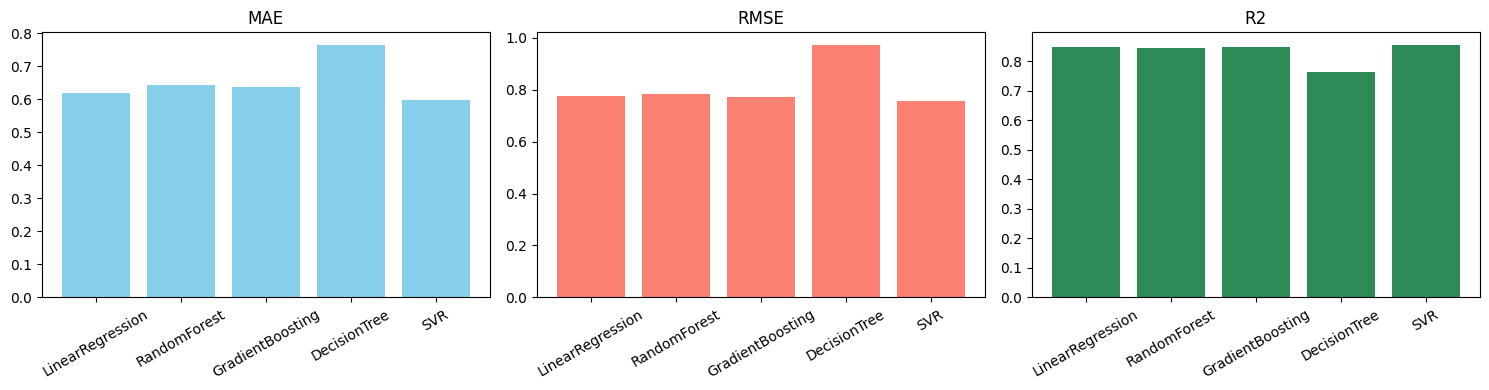

In [7]:
# Plot bar chart comparing metrics
labels = list(metrics.keys())
mae = [metrics[k]['MAE'] for k in labels]
rmse = [metrics[k]['RMSE'] for k in labels]
r2 = [metrics[k]['R2'] for k in labels]
fig, axes = plt.subplots(1,3, figsize=(15,4))
axes[0].bar(labels, mae, color='skyblue'); axes[0].set_title('MAE')
axes[1].bar(labels, rmse, color='salmon'); axes[1].set_title('RMSE')
axes[2].bar(labels, r2, color='seagreen'); axes[2].set_title('R2')
for ax in axes: ax.tick_params(axis='x', rotation=30)
save_current_fig('model_metrics_compare.png')
plt.show()

In [8]:
# Save best model
best_path = save_best_model(best_model, best_name)
best_path

2025-11-04 11:30:40 | INFO | src.train_models | Saved best model (SVR) to /workspaces/climate-ml-lab/models/saved_models/best_model.joblib


PosixPath('/workspaces/climate-ml-lab/models/saved_models/best_model.joblib')